In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv('data/df_fase1.csv')
print('Dataset carregado de data/df_fase1.csv')


Dataset carregado de data/df_fase1.csv


---
# Fase 2 — Análise Exploratória dos Dados (EDA)

**Objetivo:** Compreender o comportamento de cada feature, identificar padrões, outliers e relações entre as variáveis e a variável-alvo. Cada análise contribuirá para decisões de pré-processamento e modelagem.

## 2.0 — Importações para Visualização

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações globais de visualização
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
warnings.filterwarnings('ignore', category=FutureWarning)

# Mapeamento de rótulos para a variável-alvo (facilita a leitura dos gráficos)
label_map = {1: 'Doença Hepática', 2: 'Sem Doença'}
df['Classe'] = df['Dataset'].map(label_map)

print('✓ Bibliotecas de visualização carregadas.')

✓ Bibliotecas de visualização carregadas.


## 2.1 — Distribuição das Classes

**Objetivo:** Confirmar visualmente o desbalanceamento entre pacientes com e sem doença hepática.

**Pergunta:** Qual é a proporção exata entre as classes? O desbalanceamento é suficiente para justificar técnicas de balanceamento?

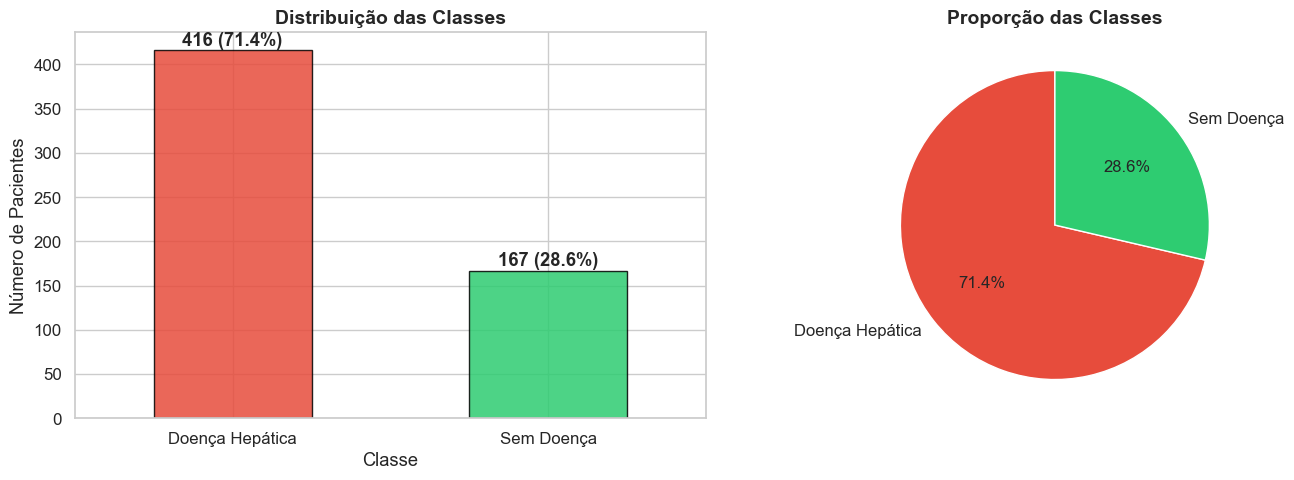

Razão entre classes: 2.49 : 1
→ O desbalanceamento (~71% vs ~29%) justifica a utilização de técnicas de balanceamento na Fase 8.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
contagem = df['Classe'].value_counts()
cores = ['#e74c3c', '#2ecc71']
contagem.plot(kind='bar', ax=axes[0], color=cores, edgecolor='black', alpha=0.85)
axes[0].set_title('Distribuição das Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Número de Pacientes')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(contagem):
    axes[0].text(i, v + 5, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Gráfico de pizza
contagem.plot(kind='pie', ax=axes[1], colors=cores, autopct='%1.1f%%',
              startangle=90, textprops={'fontsize': 12})
axes[1].set_ylabel('')
axes[1].set_title('Proporção das Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Razão entre classes: {contagem.iloc[0] / contagem.iloc[1]:.2f} : 1')
print('→ O desbalanceamento (~71% vs ~29%) justifica a utilização de técnicas de balanceamento na Fase 8.')

## 2.2 — Distribuição das Idades

**Objetivo:** Verificar se a idade é um fator diferenciador entre pacientes com e sem doença hepática.

**Perguntas:** Qual a faixa etária predominante? A distribuição de idade difere significativamente entre as duas classes?

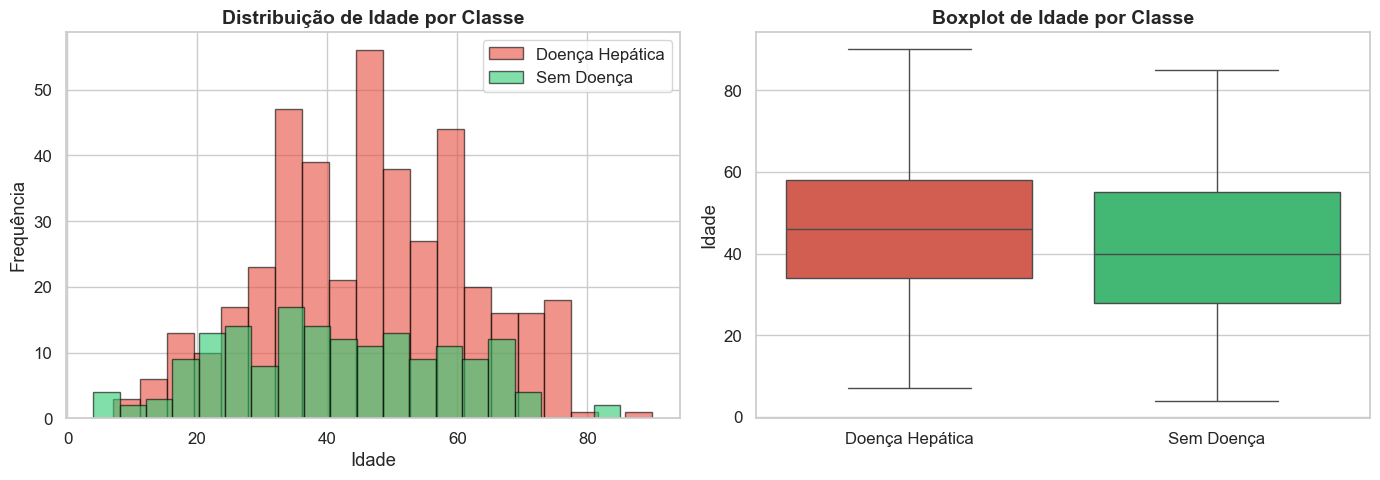

Estatísticas de Idade por Classe:
                 count  mean   std  min   25%   50%   75%   max
Classe                                                         
Doença Hepática  416.0  46.2  15.7  7.0  34.0  46.0  58.0  90.0
Sem Doença       167.0  41.2  17.0  4.0  28.0  40.0  55.0  85.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma sobreposto por classe
for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df[df['Classe'] == classe]['Age']
    axes[0].hist(subset, bins=20, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('Distribuição de Idade por Classe', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Boxplot por classe
sns.boxplot(data=df, x='Classe', y='Age', palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot de Idade por Classe', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Idade')

plt.tight_layout()
plt.show()

print('Estatísticas de Idade por Classe:')
print(df.groupby('Classe')['Age'].describe().round(1))

## 2.3 — Distribuição por Gênero

**Objetivo:** Verificar a composição de gênero do dataset e se há diferenças na proporção de doença hepática entre gêneros.

**Perguntas:** O dataset é equilibrado em termos de gênero? A prevalência da doença hepática difere entre homens e mulheres?

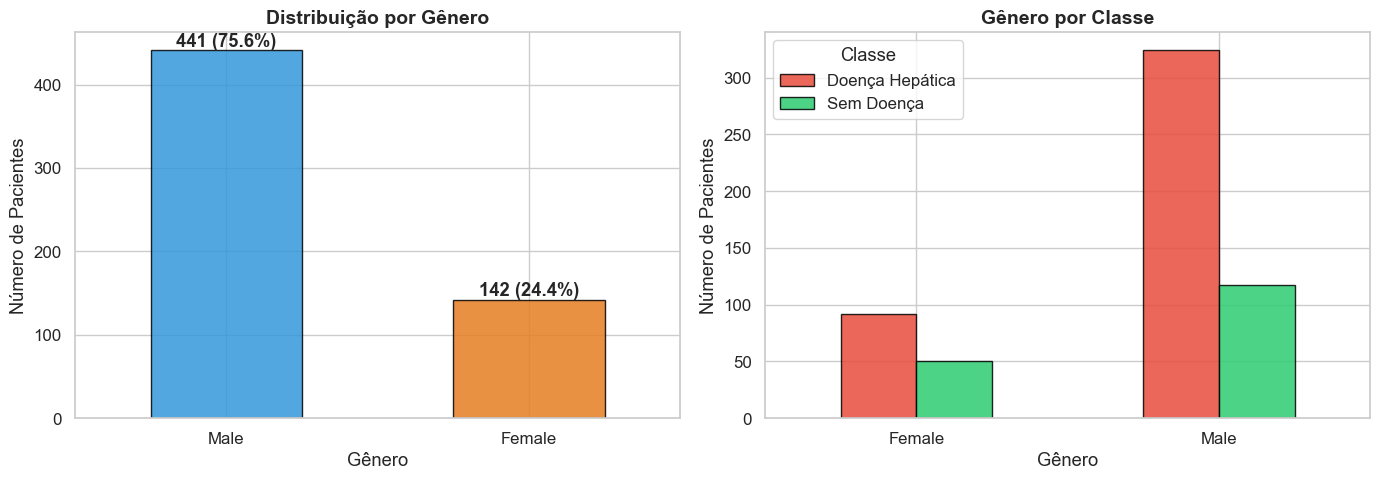

Proporção de doença hepática por gênero:
Classe  Doença Hepática  Sem Doença
Gender                             
Female             64.8        35.2
Male               73.5        26.5


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição geral de gênero
gender_counts = df['Gender'].value_counts()
gender_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e67e22'],
                   edgecolor='black', alpha=0.85)
axes[0].set_title('Distribuição por Gênero', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gênero')
axes[0].set_ylabel('Número de Pacientes')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_counts):
    axes[0].text(i, v + 5, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Gênero por classe (barras agrupadas)
ct = pd.crosstab(df['Gender'], df['Classe'])
ct.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'],
        edgecolor='black', alpha=0.85)
axes[1].set_title('Gênero por Classe', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Número de Pacientes')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Classe')

plt.tight_layout()
plt.show()

# Proporção de doença por gênero
print('Proporção de doença hepática por gênero:')
prop = pd.crosstab(df['Gender'], df['Classe'], normalize='index') * 100
print(prop.round(1))

## 2.4 — Bilirrubina Total e Bilirrubina Direta

**Objetivo:** Analisar a relação entre os dois tipos de bilirrubina e identificar possíveis outliers. Verificar se valores elevados estão associados à presença de doença.

**Perguntas:** Existe correlação forte entre as duas medidas? Pacientes com doença hepática tendem a apresentar valores mais elevados? Há outliers extremos?

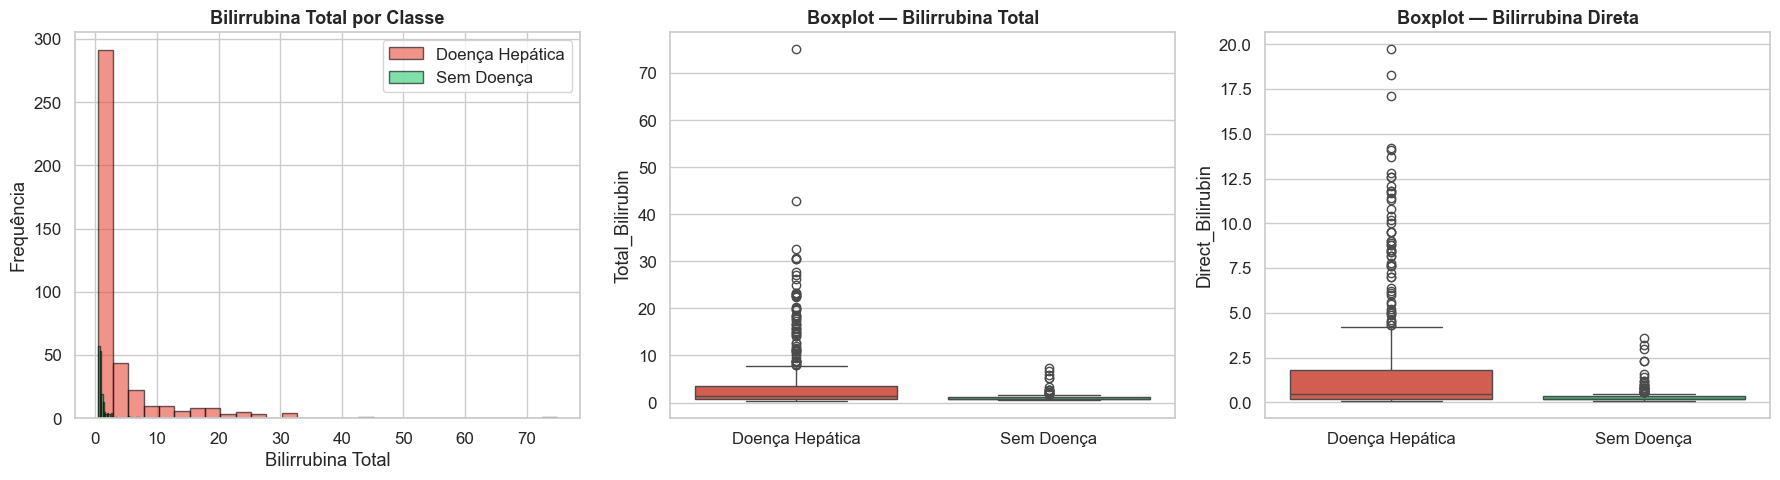

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma — Bilirrubina Total por classe
for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df[df['Classe'] == classe]['Total_Bilirubin']
    axes[0].hist(subset, bins=30, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('Bilirrubina Total por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bilirrubina Total')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Boxplot — Bilirrubina Total e Direta por classe
sns.boxplot(data=df, x='Classe', y='Total_Bilirubin', palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot — Bilirrubina Total', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

sns.boxplot(data=df, x='Classe', y='Direct_Bilirubin', palette=['#e74c3c', '#2ecc71'], ax=axes[2])
axes[2].set_title('Boxplot — Bilirrubina Direta', fontsize=13, fontweight='bold')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

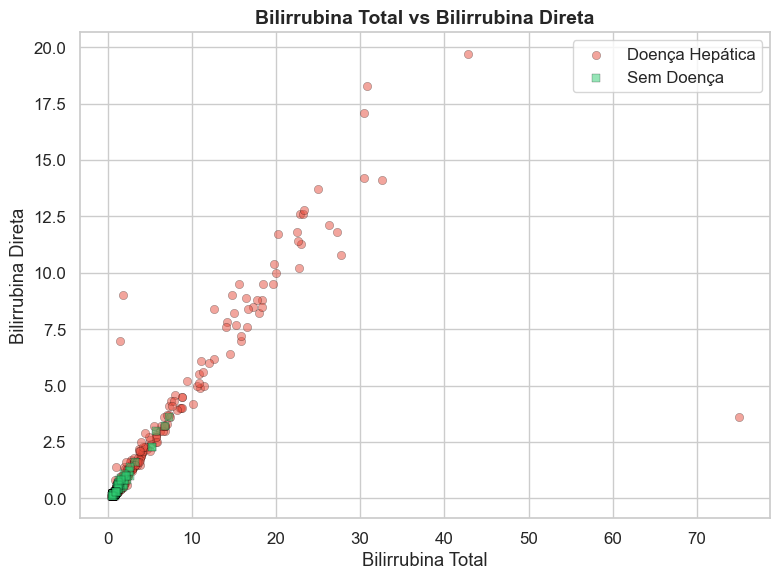

Correlação entre Bilirrubina Total e Direta: 0.875
→ Correlação muito alta, indicando potencial redundância entre essas features.


In [7]:
# Scatterplot — Bilirrubina Total vs Direta
fig, ax = plt.subplots(figsize=(8, 6))
for classe, cor, marker in zip(['Doença Hepática', 'Sem Doença'],
                                ['#e74c3c', '#2ecc71'], ['o', 's']):
    subset = df[df['Classe'] == classe]
    ax.scatter(subset['Total_Bilirubin'], subset['Direct_Bilirubin'],
               alpha=0.5, label=classe, color=cor, marker=marker, edgecolors='black', linewidth=0.3)

ax.set_title('Bilirrubina Total vs Bilirrubina Direta', fontsize=14, fontweight='bold')
ax.set_xlabel('Bilirrubina Total')
ax.set_ylabel('Bilirrubina Direta')
ax.legend()
plt.tight_layout()
plt.show()

corr_bili = df['Total_Bilirubin'].corr(df['Direct_Bilirubin'])
print(f'Correlação entre Bilirrubina Total e Direta: {corr_bili:.3f}')
print('→ Correlação muito alta, indicando potencial redundância entre essas features.')

## 2.5 — Fosfatase Alcalina

**Objetivo:** Avaliar a distribuição da fosfatase alcalina e sua associação com doença hepática.

**Perguntas:** A fosfatase alcalina apresenta valores significativamente diferentes entre as classes? Há outliers?

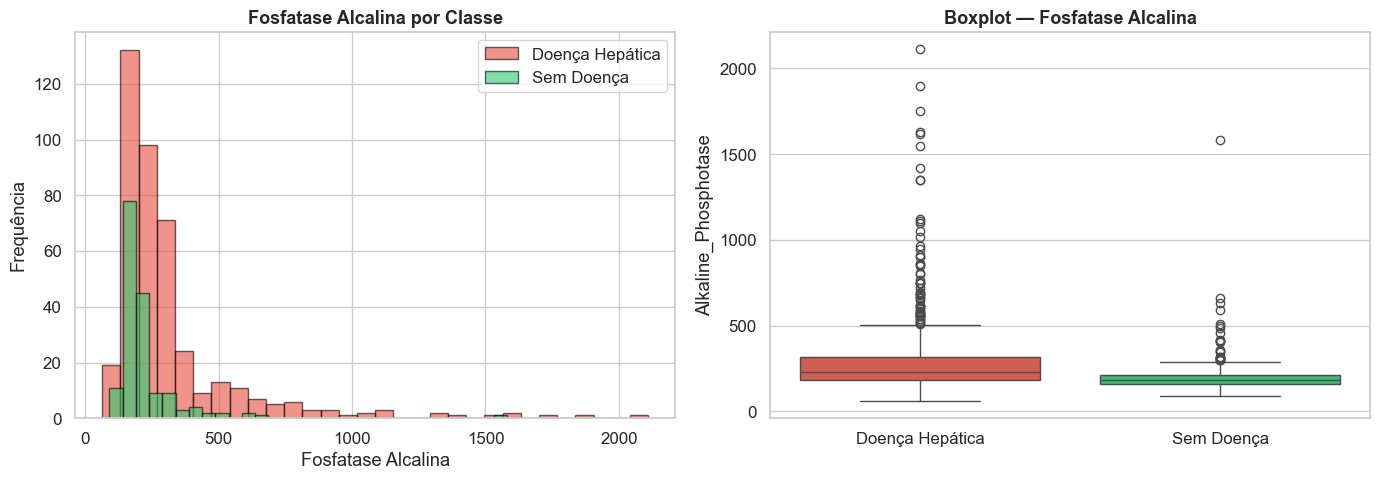

Estatísticas por Classe:
                 count   mean    std   min    25%    50%    75%     max
Classe                                                                 
Doença Hepática  416.0  319.0  268.3  63.0  186.0  229.0  315.2  2110.0
Sem Doença       167.0  219.8  141.0  90.0  161.5  186.0  213.0  1580.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df[df['Classe'] == classe]['Alkaline_Phosphotase']
    axes[0].hist(subset, bins=30, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('Fosfatase Alcalina por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fosfatase Alcalina')
axes[0].set_ylabel('Frequência')
axes[0].legend()

sns.boxplot(data=df, x='Classe', y='Alkaline_Phosphotase',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot — Fosfatase Alcalina', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Estatísticas por Classe:')
print(df.groupby('Classe')['Alkaline_Phosphotase'].describe().round(1))

## 2.6 — SGPT / ALT (Alanina Aminotransferase)

**Objetivo:** Avaliar se essa enzima hepática é um indicador relevante para a classificação.

**Perguntas:** Os valores de ALT são mais elevados nos pacientes com doença hepática? A distribuição é muito assimétrica?

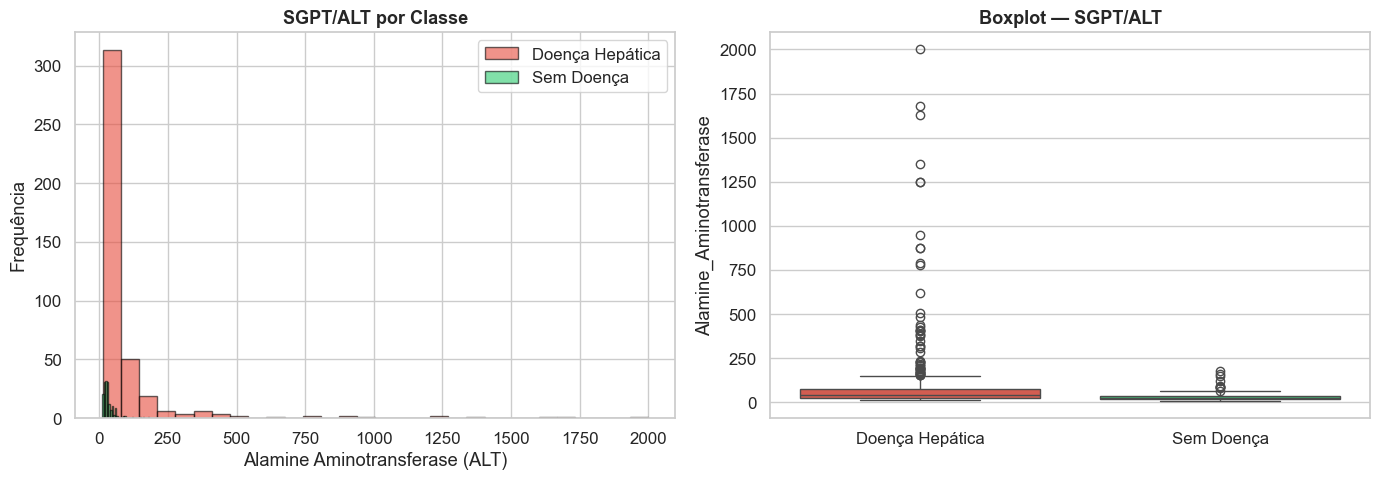

Estatísticas por Classe:
                 count  mean    std   min   25%   50%   75%     max
Classe                                                             
Doença Hepática  416.0  99.6  212.8  12.0  25.0  41.0  76.5  2000.0
Sem Doença       167.0  33.7   25.1  10.0  20.0  27.0  37.5   181.0


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df[df['Classe'] == classe]['Alamine_Aminotransferase']
    axes[0].hist(subset, bins=30, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('SGPT/ALT por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Alamine Aminotransferase (ALT)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

sns.boxplot(data=df, x='Classe', y='Alamine_Aminotransferase',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot — SGPT/ALT', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Estatísticas por Classe:')
print(df.groupby('Classe')['Alamine_Aminotransferase'].describe().round(1))

## 2.7 — SGOT / AST (Aspartato Aminotransferase)

**Objetivo:** Verificar se o SGOT/AST também é discriminativo, e analisar possível redundância com ALT.

**Perguntas:** Os valores de AST diferem entre as classes? A correlação entre ALT e AST indica redundância?

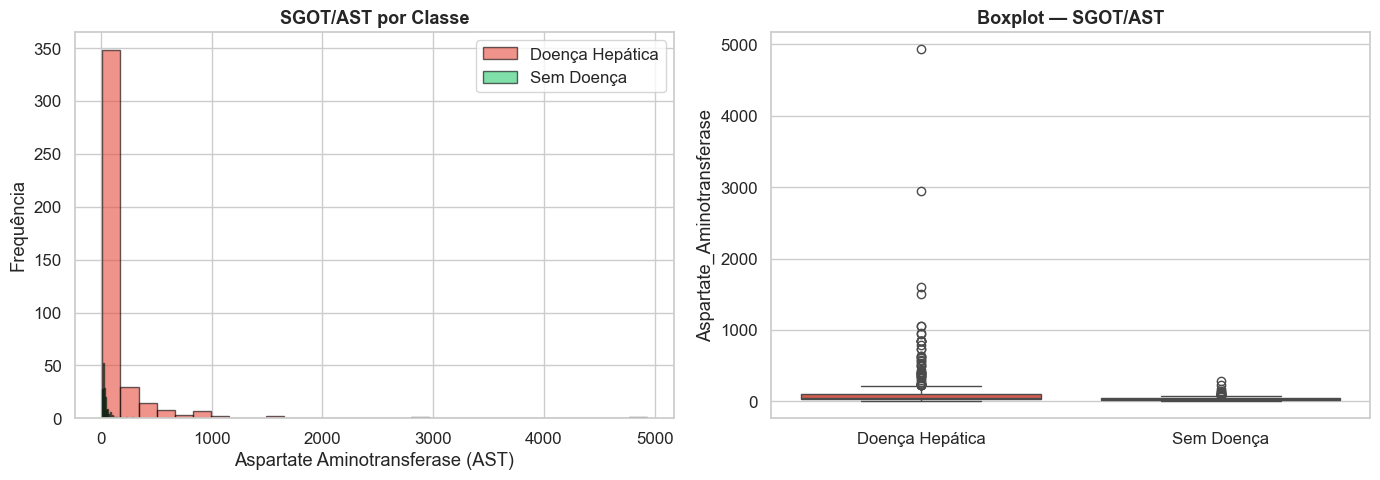

Estatísticas por Classe:
                 count   mean    std   min   25%   50%    75%     max
Classe                                                               
Doença Hepática  416.0  137.7  337.4  11.0  29.8  52.5  108.8  4929.0
Sem Doença       167.0   40.7   36.4  10.0  21.0  29.0   43.5   285.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df[df['Classe'] == classe]['Aspartate_Aminotransferase']
    axes[0].hist(subset, bins=30, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('SGOT/AST por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Aspartate Aminotransferase (AST)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

sns.boxplot(data=df, x='Classe', y='Aspartate_Aminotransferase',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot — SGOT/AST', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Estatísticas por Classe:')
print(df.groupby('Classe')['Aspartate_Aminotransferase'].describe().round(1))

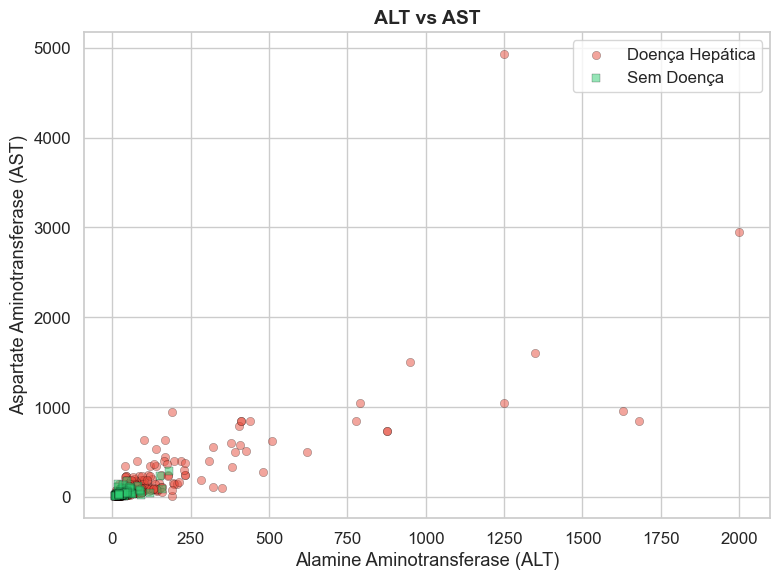

Correlação entre ALT e AST: 0.792
→ Alta correlação entre as duas enzimas, o que é esperado clinicamente.


In [11]:
# Scatterplot ALT vs AST — verificar redundância
fig, ax = plt.subplots(figsize=(8, 6))
for classe, cor, marker in zip(['Doença Hepática', 'Sem Doença'],
                                ['#e74c3c', '#2ecc71'], ['o', 's']):
    subset = df[df['Classe'] == classe]
    ax.scatter(subset['Alamine_Aminotransferase'], subset['Aspartate_Aminotransferase'],
               alpha=0.5, label=classe, color=cor, marker=marker, edgecolors='black', linewidth=0.3)

ax.set_title('ALT vs AST', fontsize=14, fontweight='bold')
ax.set_xlabel('Alamine Aminotransferase (ALT)')
ax.set_ylabel('Aspartate Aminotransferase (AST)')
ax.legend()
plt.tight_layout()
plt.show()

corr_alt_ast = df['Alamine_Aminotransferase'].corr(df['Aspartate_Aminotransferase'])
print(f'Correlação entre ALT e AST: {corr_alt_ast:.3f}')
print('→ Alta correlação entre as duas enzimas, o que é esperado clinicamente.')

## 2.8 — Proteínas Totais

**Objetivo:** Verificar se o nível de proteínas totais está associado ao diagnóstico de doença hepática.

**Perguntas:** A distribuição difere entre pacientes com e sem doença? Há sobreposição significativa entre as classes?

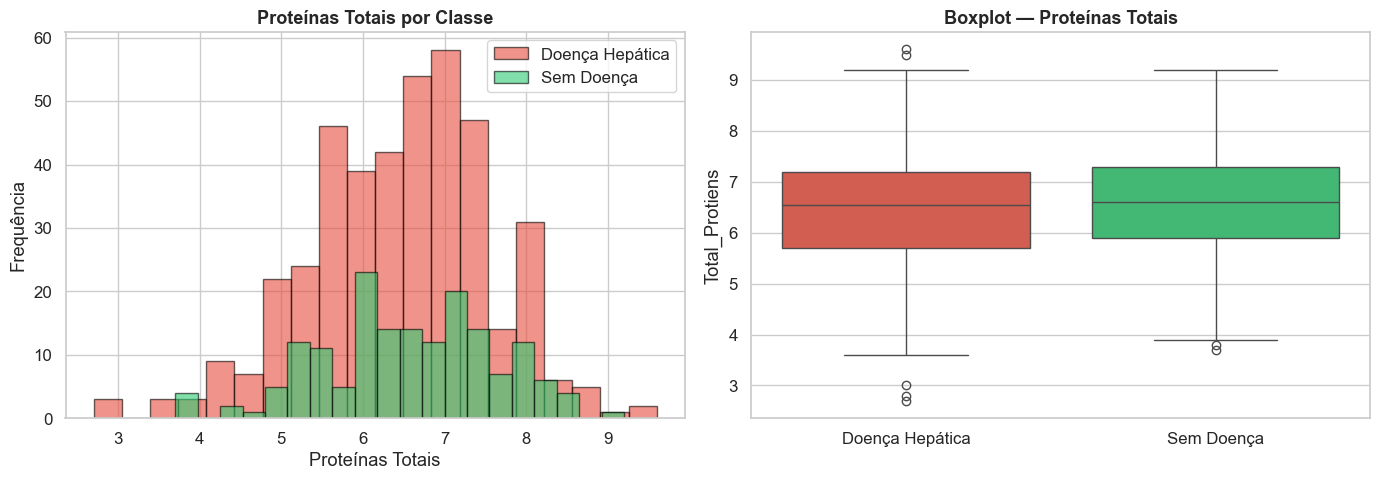

Estatísticas por Classe:
                 count  mean   std  min  25%   50%  75%  max
Classe                                                      
Doença Hepática  416.0  6.46  1.09  2.7  5.7  6.55  7.2  9.6
Sem Doença       167.0  6.54  1.06  3.7  5.9  6.60  7.3  9.2


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df[df['Classe'] == classe]['Total_Protiens']
    axes[0].hist(subset, bins=20, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('Proteínas Totais por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Proteínas Totais')
axes[0].set_ylabel('Frequência')
axes[0].legend()

sns.boxplot(data=df, x='Classe', y='Total_Protiens',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot — Proteínas Totais', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Estatísticas por Classe:')
print(df.groupby('Classe')['Total_Protiens'].describe().round(2))

## 2.9 — Albumina

**Objetivo:** Avaliar se níveis baixos de albumina estão associados à doença hepática.

**Perguntas:** Pacientes com doença hepática apresentam níveis mais baixos de albumina? A albumina tem poder discriminativo?

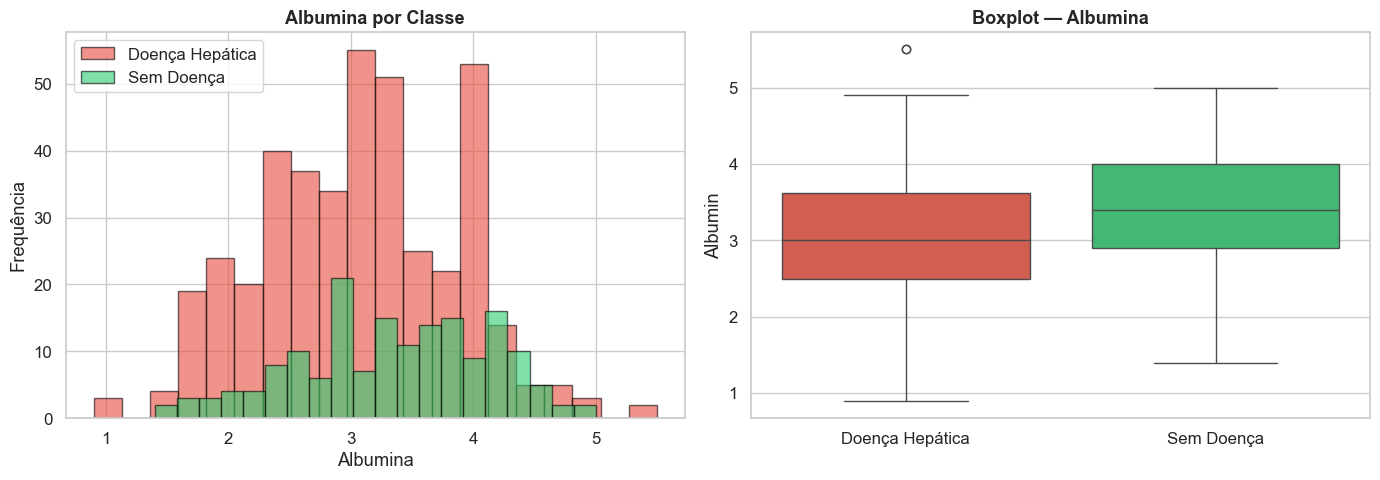

Estatísticas por Classe:
                 count  mean   std  min  25%  50%   75%  max
Classe                                                      
Doença Hepática  416.0  3.06  0.79  0.9  2.5  3.0  3.62  5.5
Sem Doença       167.0  3.34  0.78  1.4  2.9  3.4  4.00  5.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df[df['Classe'] == classe]['Albumin']
    axes[0].hist(subset, bins=20, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('Albumina por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Albumina')
axes[0].set_ylabel('Frequência')
axes[0].legend()

sns.boxplot(data=df, x='Classe', y='Albumin',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot — Albumina', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Estatísticas por Classe:')
print(df.groupby('Classe')['Albumin'].describe().round(2))

## 2.10 — Razão Albumina/Globulina (A/G Ratio)

**Objetivo:** Analisar a razão A/G como indicador de doença, considerando que essa coluna possui valores ausentes.

**Perguntas:** A razão A/G é menor em pacientes com doença hepática? A presença de valores ausentes está associada a alguma classe específica?

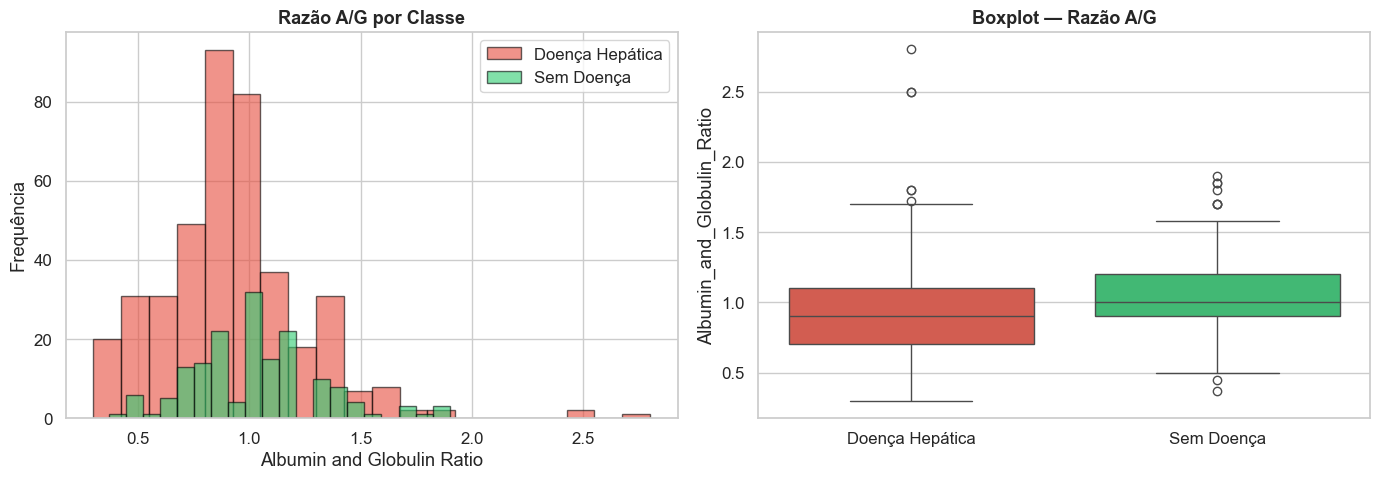

Estatísticas por Classe (excluindo NaN):
                 count  mean   std   min  25%  50%  75%  max
Classe                                                      
Doença Hepática  414.0  0.91  0.33  0.30  0.7  0.9  1.1  2.8
Sem Doença       165.0  1.03  0.29  0.37  0.9  1.0  1.2  1.9

Registros com A/G ausente: 4


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Usar apenas registros sem valores ausentes nesta feature
df_ag = df.dropna(subset=['Albumin_and_Globulin_Ratio'])

for classe, cor in zip(['Doença Hepática', 'Sem Doença'], ['#e74c3c', '#2ecc71']):
    subset = df_ag[df_ag['Classe'] == classe]['Albumin_and_Globulin_Ratio']
    axes[0].hist(subset, bins=20, alpha=0.6, label=classe, color=cor, edgecolor='black')
axes[0].set_title('Razão A/G por Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Albumin and Globulin Ratio')
axes[0].set_ylabel('Frequência')
axes[0].legend()

sns.boxplot(data=df_ag, x='Classe', y='Albumin_and_Globulin_Ratio',
            palette=['#e74c3c', '#2ecc71'], ax=axes[1])
axes[1].set_title('Boxplot — Razão A/G', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Estatísticas por Classe (excluindo NaN):')
print(df_ag.groupby('Classe')['Albumin_and_Globulin_Ratio'].describe().round(2))
print(f'\nRegistros com A/G ausente: {df["Albumin_and_Globulin_Ratio"].isnull().sum()}')

## 2.11 — Relações entre Features e Variável-Alvo

**Objetivo:** Obter uma visão global das relações bivariadas entre as features e identificar possíveis padrões de separabilidade.

**Perguntas:** Existem pares de features que separam bem as classes? Alguma feature isoladamente é suficiente para a classificação?

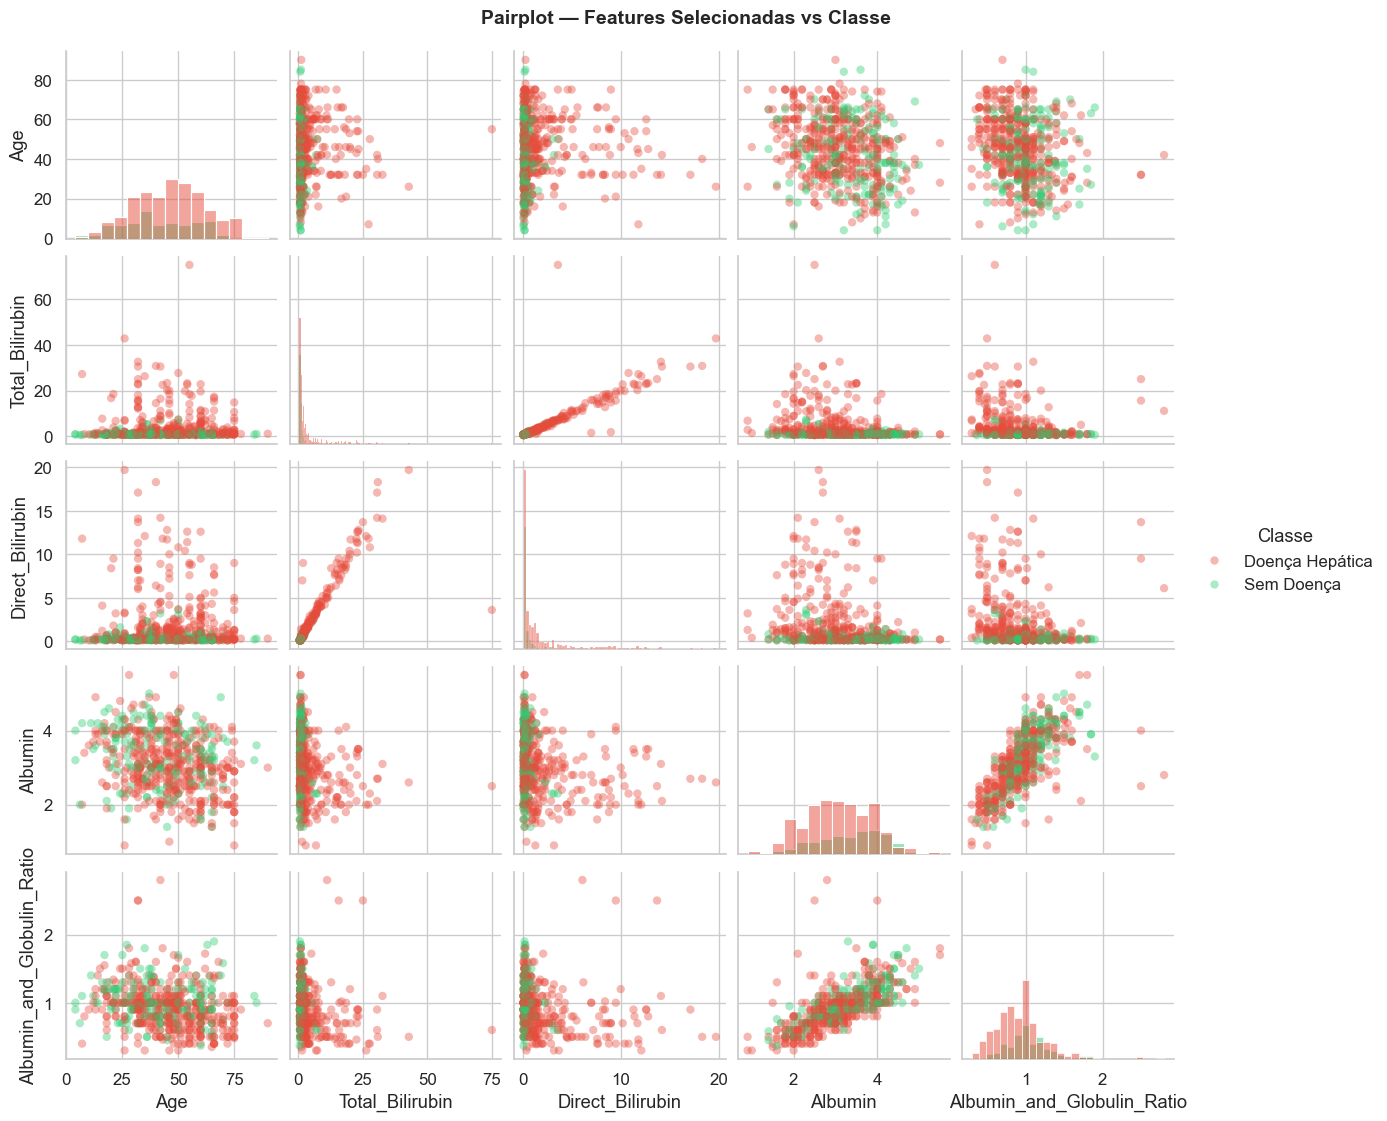

In [15]:
# Pairplot com um subconjunto de features mais relevantes para manter legibilidade
features_pairplot = ['Age', 'Total_Bilirubin', 'Direct_Bilirubin',
                     'Albumin', 'Albumin_and_Globulin_Ratio', 'Classe']

g = sns.pairplot(df[features_pairplot].dropna(), hue='Classe',
                 palette=['#e74c3c', '#2ecc71'],
                 diag_kind='hist', plot_kws={'alpha': 0.4, 'edgecolor': 'none'},
                 height=2.2, aspect=1.1)
g.figure.suptitle('Pairplot — Features Selecionadas vs Classe', y=1.02,
                  fontsize=14, fontweight='bold')
plt.show()

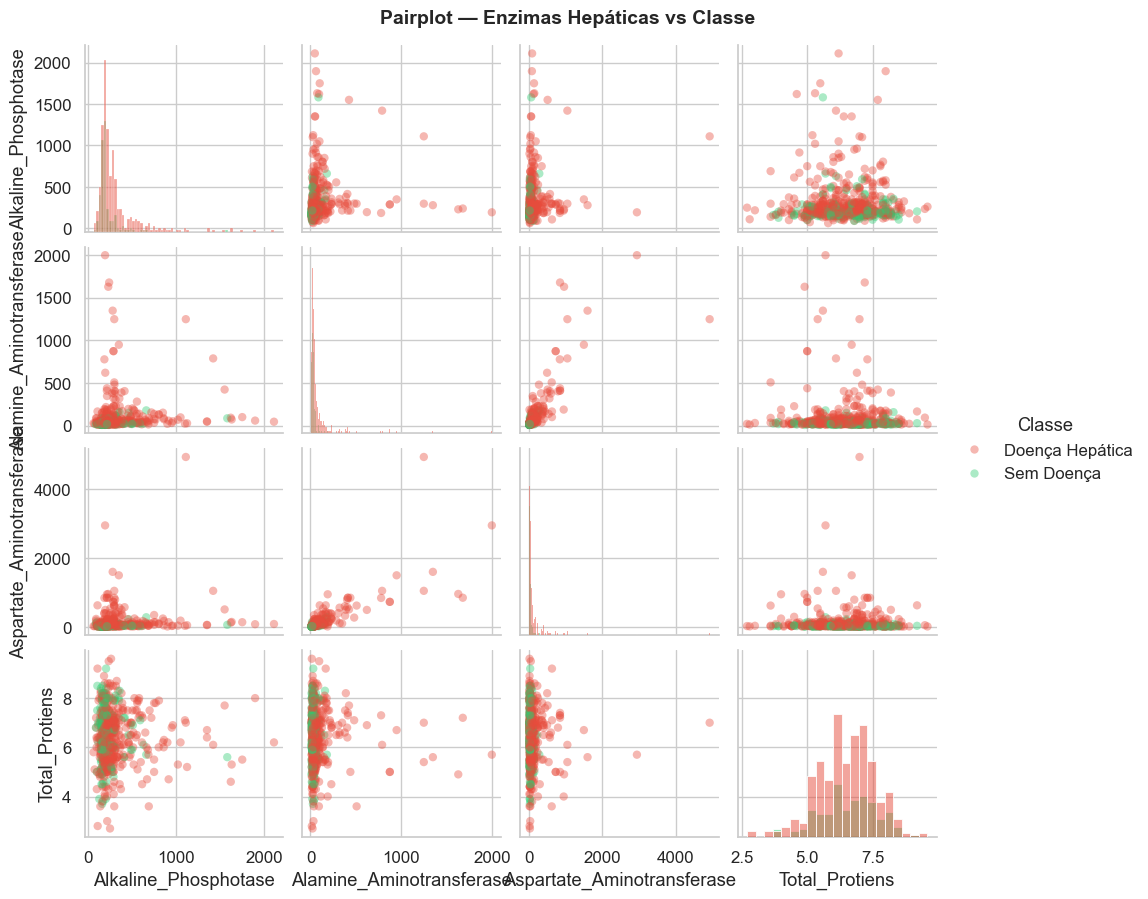

In [16]:
# Pairplot com as enzimas hepáticas
features_enzimas = ['Alkaline_Phosphotase', 'Alamine_Aminotransferase',
                    'Aspartate_Aminotransferase', 'Total_Protiens', 'Classe']

g2 = sns.pairplot(df[features_enzimas].dropna(), hue='Classe',
                  palette=['#e74c3c', '#2ecc71'],
                  diag_kind='hist', plot_kws={'alpha': 0.4, 'edgecolor': 'none'},
                  height=2.2, aspect=1.1)
g2.figure.suptitle('Pairplot — Enzimas Hepáticas vs Classe', y=1.02,
                   fontsize=14, fontweight='bold')
plt.show()

## 2.12 — Possíveis Outliers

**Objetivo:** Identificar valores extremos que possam distorcer a modelagem.

**Perguntas:** Quais features possuem outliers? Os outliers são valores plausíveis ou erros de medição? Estão associados a uma classe específica?

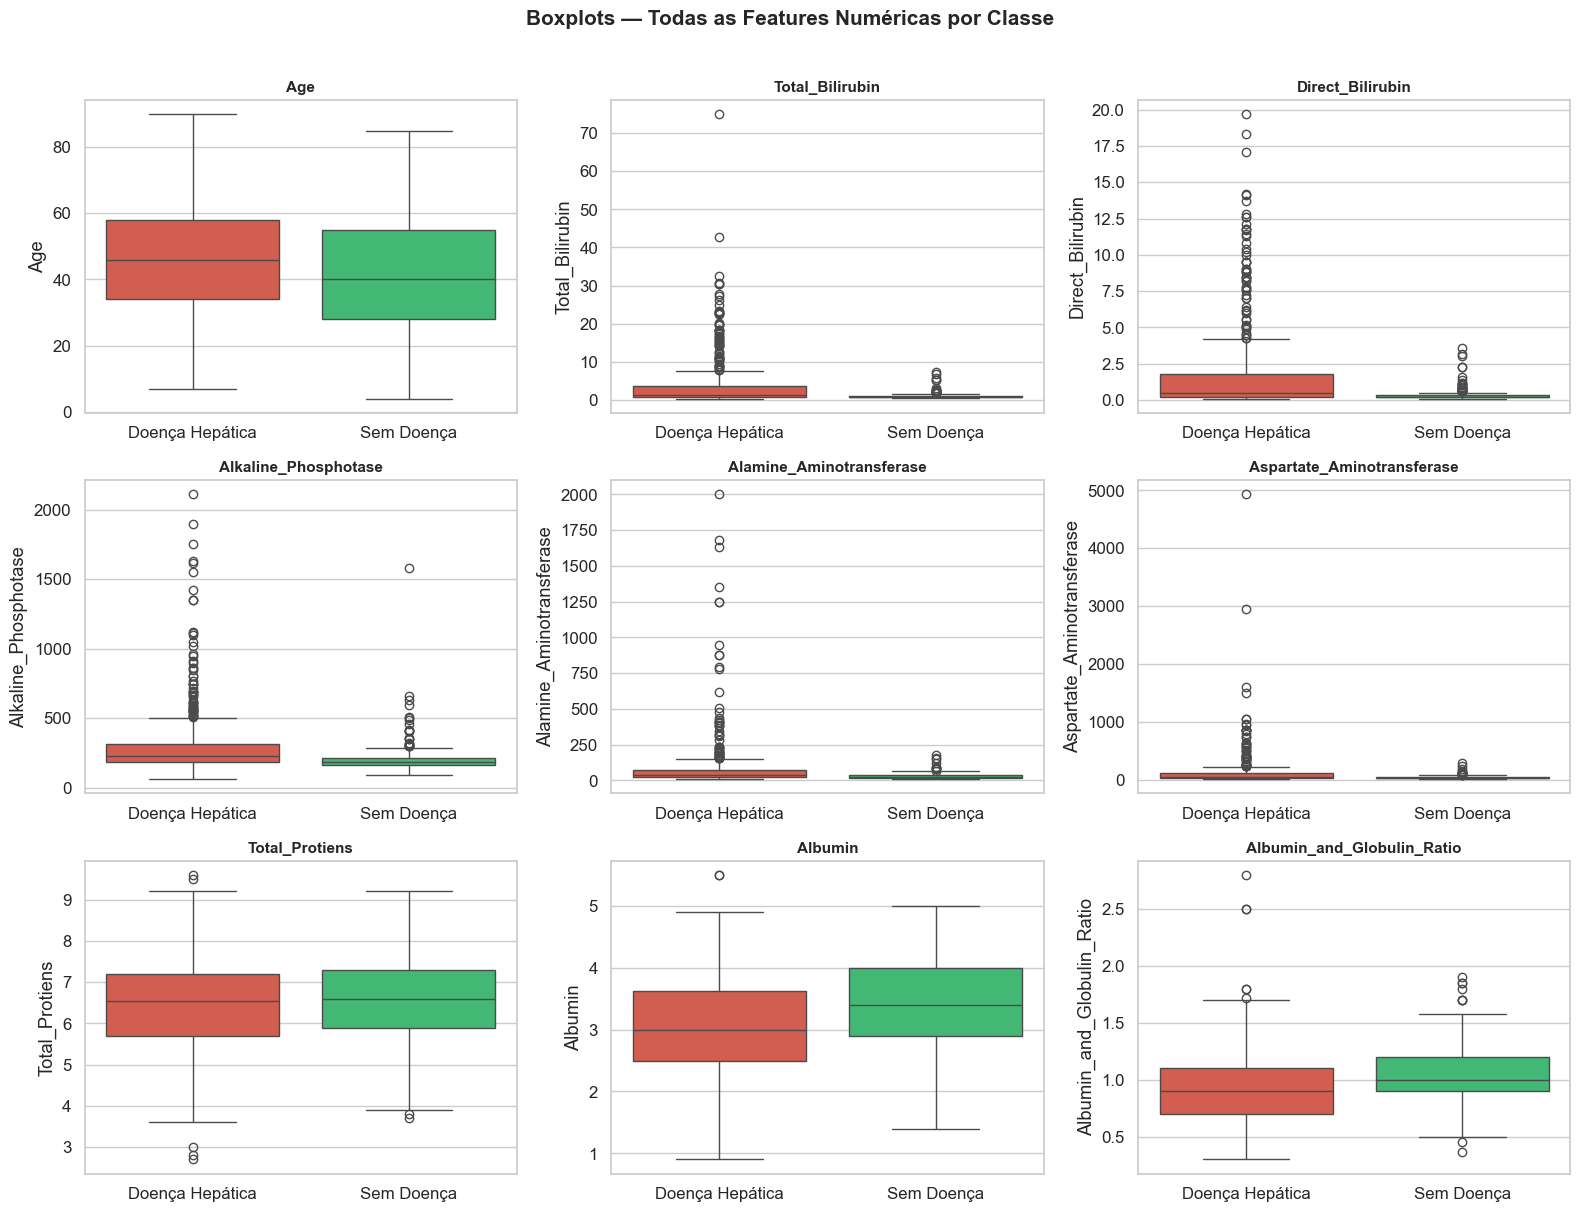

In [17]:
# Boxplots de todas as features numéricas (escala normalizada para comparação)
features_numericas = ['Age', 'Total_Bilirubin', 'Direct_Bilirubin',
                      'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
                      'Aspartate_Aminotransferase', 'Total_Protiens',
                      'Albumin', 'Albumin_and_Globulin_Ratio']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_numericas):
    sns.boxplot(data=df, y=col, x='Classe', palette=['#e74c3c', '#2ecc71'], ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — Todas as Features Numéricas por Classe',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# Quantificação de outliers pelo método IQR
print('Contagem de outliers por feature (método IQR — 1.5 × IQR):')
print('-' * 55)

resumo_outliers = []
for col in features_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    n_out = len(outliers)
    pct = n_out / len(df) * 100
    resumo_outliers.append({'Feature': col, 'Outliers': n_out, '%': round(pct, 1)})
    print(f'  {col:35s} → {n_out:3d} outliers ({pct:.1f}%)')

print('-' * 55)
print('\n→ Features com maior concentração de outliers devem ser analisadas com cuidado.')
print('  Como os valores são clinicamente plausíveis, optaremos por NÃO remover outliers.')
print('  A padronização (StandardScaler) e modelos robustos (Random Forest) ajudam a mitigar o impacto.')

Contagem de outliers por feature (método IQR — 1.5 × IQR):
-------------------------------------------------------
  Age                                 →   0 outliers (0.0%)
  Total_Bilirubin                     →  84 outliers (14.4%)
  Direct_Bilirubin                    →  81 outliers (13.9%)
  Alkaline_Phosphotase                →  69 outliers (11.8%)
  Alamine_Aminotransferase            →  73 outliers (12.5%)
  Aspartate_Aminotransferase          →  66 outliers (11.3%)
  Total_Protiens                      →   8 outliers (1.4%)
  Albumin                             →   0 outliers (0.0%)
  Albumin_and_Globulin_Ratio          →  10 outliers (1.7%)
-------------------------------------------------------

→ Features com maior concentração de outliers devem ser analisadas com cuidado.
  Como os valores são clinicamente plausíveis, optaremos por NÃO remover outliers.
  A padronização (StandardScaler) e modelos robustos (Random Forest) ajudam a mitigar o impacto.


## 2.13 — Correlações entre Variáveis

**Objetivo:** Identificar multicolinearidade entre features e possíveis redundâncias.

**Perguntas:** Quais pares de features possuem correlação alta? A alta correlação entre `Total_Bilirubin` e `Direct_Bilirubin` sugere a remoção de uma delas? Há features com baixa correlação com a variável-alvo?

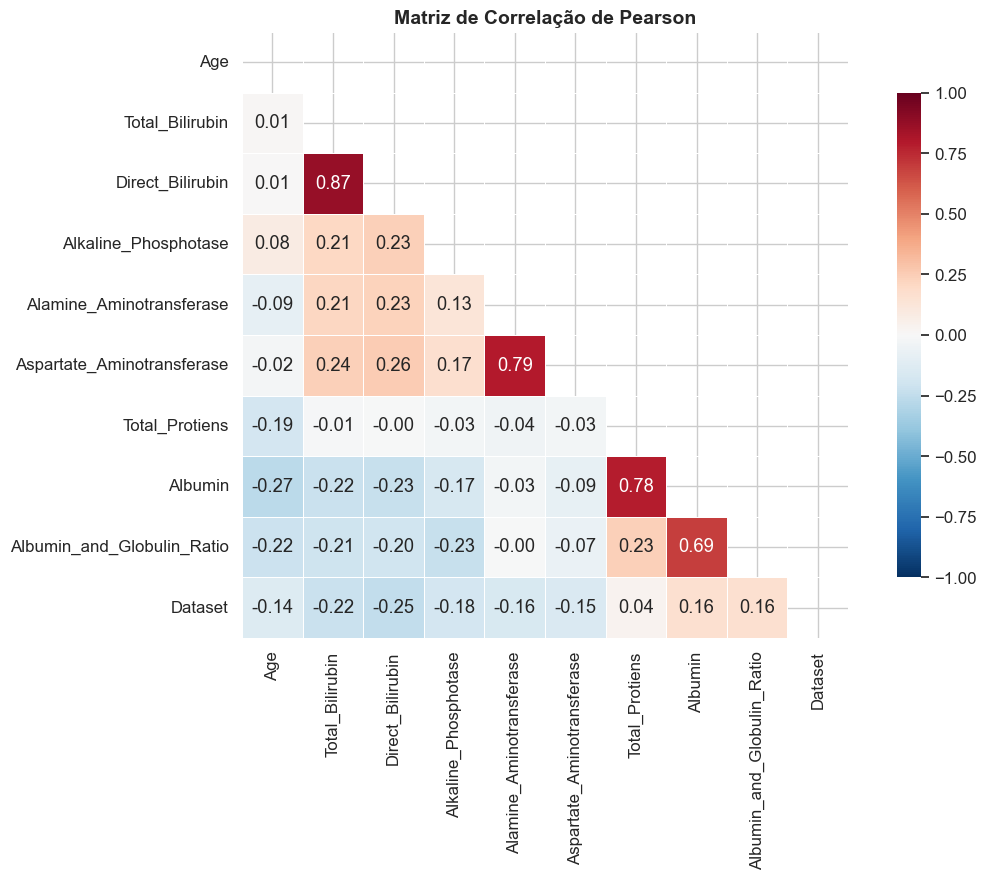

In [19]:
# Matriz de correlação de Pearson
colunas_corr = features_numericas + ['Dataset']
corr_matrix = df[colunas_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Matriz de Correlação de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

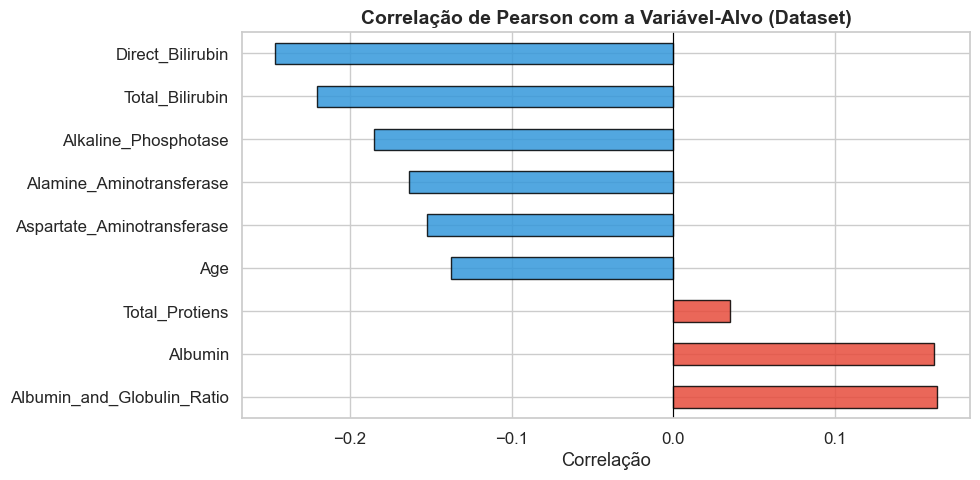

Correlação com a variável-alvo (Dataset):
Albumin_and_Globulin_Ratio    0.163
Albumin                       0.161
Total_Protiens                0.035
Age                          -0.137
Aspartate_Aminotransferase   -0.152
Alamine_Aminotransferase     -0.163
Alkaline_Phosphotase         -0.185
Total_Bilirubin              -0.220
Direct_Bilirubin             -0.246

Nota: Valores positivos indicam associação com classe 2 (sem doença).
      Valores negativos indicam associação com classe 1 (doença).


In [20]:
# Correlação de cada feature com a variável-alvo
corr_com_alvo = corr_matrix['Dataset'].drop('Dataset').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
cores_barras = ['#e74c3c' if v > 0 else '#3498db' for v in corr_com_alvo]
corr_com_alvo.plot(kind='barh', color=cores_barras, edgecolor='black', alpha=0.85, ax=ax)
ax.set_title('Correlação de Pearson com a Variável-Alvo (Dataset)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlação')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Correlação com a variável-alvo (Dataset):')
print(corr_com_alvo.round(3).to_string())
print('\nNota: Valores positivos indicam associação com classe 2 (sem doença).')
print('      Valores negativos indicam associação com classe 1 (doença).')

In [21]:
# Pares de features com alta correlação (|r| > 0.7)
print('Pares de features com alta correlação (|r| > 0.7):')
print('-' * 60)
pares_alta_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            val = corr_matrix.iloc[i, j]
            pares_alta_corr.append((col_i, col_j, val))
            print(f'  {col_i} ↔ {col_j}: {val:.3f}')

if not pares_alta_corr:
    print('  Nenhum par encontrado.')
print('-' * 60)
print('\n→ Features com alta correlação entre si podem introduzir multicolinearidade.')
print('  Isso será considerado na etapa de seleção de features e modelagem.')

Pares de features com alta correlação (|r| > 0.7):
------------------------------------------------------------
  Total_Bilirubin ↔ Direct_Bilirubin: 0.875
  Alamine_Aminotransferase ↔ Aspartate_Aminotransferase: 0.792
  Total_Protiens ↔ Albumin: 0.784
------------------------------------------------------------

→ Features com alta correlação entre si podem introduzir multicolinearidade.
  Isso será considerado na etapa de seleção de features e modelagem.


## 2.14 — Resumo das Descobertas da EDA

### Principais observações

1. **Desbalanceamento confirmado:** A classe de doença hepática representa ~71% dos registros. Técnicas de balanceamento serão exploradas na Fase 8.

2. **Idade:** A distribuição de idade é semelhante entre as classes, com mediana ligeiramente maior nos pacientes com doença. A idade sozinha não é um forte discriminador.

3. **Gênero:** O dataset possui predominância masculina (~76%). A proporção de doença pode variar entre gêneros.

4. **Bilirrubina (Total e Direta):** Pacientes com doença tendem a apresentar valores mais elevados. Alta correlação entre Total e Direta (~0.87), indicando potencial redundância.

5. **Enzimas hepáticas (ALT, AST, Fosfatase Alcalina):** Valores mais elevados nos pacientes com doença, com distribuições muito assimétricas e outliers extremos. ALT e AST possuem alta correlação entre si.

6. **Proteínas Totais:** Sobreposição significativa entre as classes. Poder discriminativo baixo isoladamente.

7. **Albumina e Razão A/G:** Pacientes com doença tendem a ter valores mais baixos de albumina e razão A/G. Estas features têm potencial discriminativo.

8. **Outliers:** Presentes principalmente em bilirrubina e enzimas hepáticas. Como são clinicamente plausíveis, serão mantidos. Modelos robustos e padronização ajudarão a lidar com eles.

9. **Multicolinearidade:** Pares com alta correlação (Total/Direct Bilirubin, ALT/AST, Albumin/A-G Ratio) devem ser monitorados. Não serão removidos a priori, mas modelos de regularização podem lidar com a redundância.

### Decisões para as próximas fases

- **Outliers:** Manter — valores clinicamente plausíveis.
- **Features:** Manter todas inicialmente. Avaliar remoção de features redundantes se necessário.
- **Padronização:** Essencial para modelos sensíveis à escala, dadas as escalas muito diferentes entre as features.
- **Balanceamento:** Necessário — explorar `class_weight` e SMOTE na Fase 8.

### Checklist de Conclusão da Fase 2

- ✅ Distribuição das classes analisada e desbalanceamento confirmado.
- ✅ Distribuição de idade analisada por classe.
- ✅ Distribuição por gênero analisada e proporção de doença calculada.
- ✅ Bilirrubina total e direta analisadas, correlação calculada.
- ✅ Fosfatase alcalina analisada por classe.
- ✅ SGPT/ALT analisada por classe.
- ✅ SGOT/AST analisada por classe, correlação com ALT verificada.
- ✅ Proteínas totais analisadas.
- ✅ Albumina analisada por classe.
- ✅ Razão A/G analisada, valores ausentes verificados.
- ✅ Pairplots gerados para relações bivariadas.
- ✅ Outliers identificados e quantificados — decisão: manter.
- ✅ Matriz de correlação gerada e multicolinearidade identificada.
- ✅ Resumo das descobertas documentado.

In [22]:
# Remover a coluna auxiliar 'Classe' criada para os gráficos
df.drop(columns=['Classe'], inplace=True)
print('✓ Coluna auxiliar "Classe" removida. DataFrame restaurado ao estado original.')
print(f'  Colunas atuais: {list(df.columns)}')

✓ Coluna auxiliar "Classe" removida. DataFrame restaurado ao estado original.
  Colunas atuais: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']
